# 🎓 Student Exam Score Predictor
### End-to-End ML Pipeline: Data Cleaning → ColumnTransformer → Model Training

**Dataset:** [Student Performance Factors](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors) — 6,607 students  
**Goal:** Predict a student's exam score and find the minimum weekly study hours to pass (≥ 60)  
**Author:** Ameer Hamza Nasir  

---

## 1. Imports & Setup

Pure sklearn only — no extra packages needed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print("All libraries loaded ✅  (pure sklearn — no category-encoders needed)")

All libraries loaded ✅  (pure sklearn — no category-encoders needed)


## 2. Load & Explore the Raw Data

In [3]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nDtypes:")
print(df.dtypes)

Shape: 6607 rows × 20 columns

Dtypes:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object


In [5]:
df.head(3)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Columns with missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Total missing cells: 235


In [7]:
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


## 3. Data Cleaning

Drop all rows with any NaN in one shot — dataset is large enough that we lose nothing meaningful.

In [8]:
rows_before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Rows dropped : {rows_before - len(df)}")
print(f"Rows remaining: {len(df)}")

assert df.isnull().sum().sum() == 0, "NaNs still present!"
print("No missing values ✅")

Rows dropped : 229
Rows remaining: 6378
No missing values ✅


## 4. Exploratory Data Analysis (EDA)

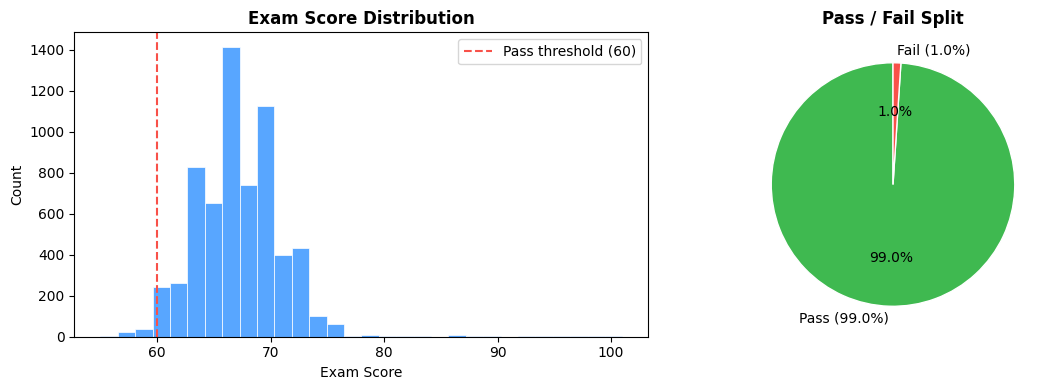

Pass rate: 99.0%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Exam_Score"], bins=30, color="#58a6ff", edgecolor="white", linewidth=0.5)
axes[0].axvline(60, color="#f85149", linestyle="--", linewidth=1.5, label="Pass threshold (60)")
axes[0].set_title("Exam Score Distribution", fontweight="bold")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")
axes[0].legend()

pass_rate = (df["Exam_Score"] >= 60).mean() * 100
axes[1].pie(
    [(df["Exam_Score"] >= 60).sum(), (df["Exam_Score"] < 60).sum()],
    labels=[f"Pass ({pass_rate:.1f}%)", f"Fail ({100-pass_rate:.1f}%)"],
    colors=["#3fb950", "#f85149"], autopct="%1.1f%%",
    startangle=90, wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Pass / Fail Split", fontweight="bold")

plt.tight_layout()
plt.savefig("exam_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Pass rate: {pass_rate:.1f}%")

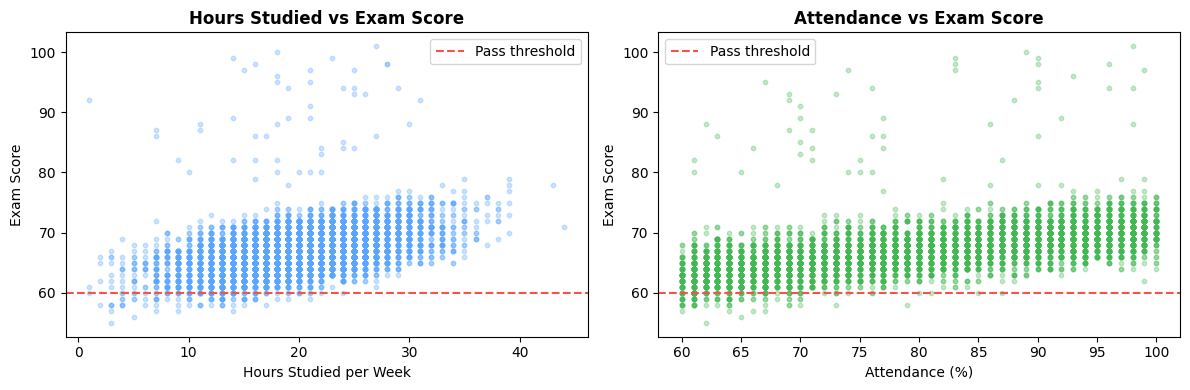

Passers avg hours     : 20.1h
Failers avg hours     : 10.4h
Passers avg attendance: 80.2%
Failers avg attendance: 63.8%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.3, s=10, color="#58a6ff")
axes[0].axhline(60, color="#f85149", linestyle="--", linewidth=1.5, label="Pass threshold")
axes[0].set_title("Hours Studied vs Exam Score", fontweight="bold")
axes[0].set_xlabel("Hours Studied per Week")
axes[0].set_ylabel("Exam Score")
axes[0].legend()

axes[1].scatter(df["Attendance"], df["Exam_Score"], alpha=0.3, s=10, color="#3fb950")
axes[1].axhline(60, color="#f85149", linestyle="--", linewidth=1.5, label="Pass threshold")
axes[1].set_title("Attendance vs Exam Score", fontweight="bold")
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("Exam Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("hours_attendance_vs_score.png", dpi=150, bbox_inches="tight")
plt.show()

passers = df[df["Exam_Score"] >= 60]
failers = df[df["Exam_Score"] < 60]
print(f"Passers avg hours     : {passers['Hours_Studied'].mean():.1f}h")
print(f"Failers avg hours     : {failers['Hours_Studied'].mean():.1f}h")
print(f"Passers avg attendance: {passers['Attendance'].mean():.1f}%")
print(f"Failers avg attendance: {failers['Attendance'].mean():.1f}%")

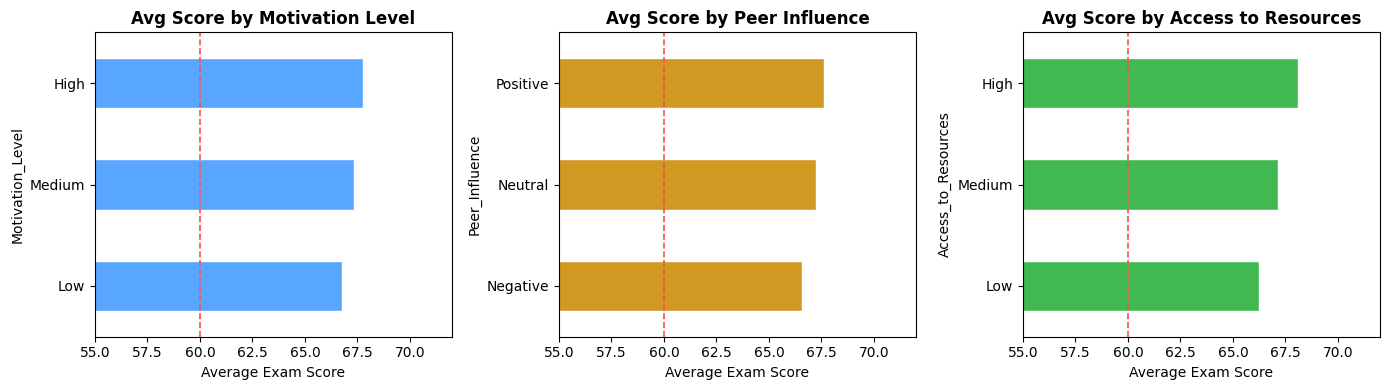

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(
    axes,
    ["Motivation_Level", "Peer_Influence", "Access_to_Resources"],
    ["#58a6ff", "#d29922", "#3fb950"]
):
    means = df.groupby(col)["Exam_Score"].mean().sort_values()
    means.plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.axvline(60, color="#f85149", linestyle="--", linewidth=1.2)
    ax.set_title(f"Avg Score by {col.replace(chr(95), chr(32))}", fontweight="bold")
    ax.set_xlabel("Average Exam Score")
    ax.set_xlim(55, 72)
plt.tight_layout()
plt.savefig("categorical_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Define Column Groups

Three groups — each gets a different preprocessing treatment.

In [13]:
ORDINAL_COLS = [
    "Parental_Involvement",     # Low / Medium / High
    "Access_to_Resources",      # Low / Medium / High
    "Motivation_Level",         # Low / Medium / High
    "Family_Income",            # Low / Medium / High
    "Teacher_Quality",          # Low / Medium / High
    "Peer_Influence",           # Negative / Neutral / Positive
    "Parental_Education_Level", # High School / College / Postgraduate
    "Distance_from_Home",       # Far / Moderate / Near
]

BINARY_COLS = [
    "Extracurricular_Activities",  # Yes / No
    "Internet_Access",             # Yes / No
    "Learning_Disabilities",       # Yes / No
    "School_Type",                 # Public / Private
    "Gender",                      # Male / Female
]

NUM_COLS = [
    "Hours_Studied", "Attendance", "Sleep_Hours",
    "Previous_Scores", "Tutoring_Sessions", "Physical_Activity",
]

TARGET = "Exam_Score"

print(f"Ordinal : {len(ORDINAL_COLS)} columns")
print(f"Binary  : {len(BINARY_COLS)} columns")
print(f"Numeric : {len(NUM_COLS)} columns")

Ordinal : 8 columns
Binary  : 5 columns
Numeric : 6 columns


## 6. Build the Pipeline

**Why Pipeline instead of manual loops?**

| Old approach (loop) | New approach (Pipeline) |
|---|---|
| `le` gets overwritten each iteration | Each encoder remembers its own column |
| 3 separate `.joblib` files | 1 single `pipeline.joblib` file |
| Must manually encode in the app | `pipeline.predict(raw_df)` works directly |
| Easy to apply wrong encoder to wrong col | Impossible — wired by ColumnTransformer |
| *Unseen data* errors at prediction time | Never — same object used for fit and predict |

In [14]:
ordinal_categories = [
    ["Low", "Medium", "High"],              # Parental_Involvement
    ["Low", "Medium", "High"],              # Access_to_Resources
    ["Low", "Medium", "High"],              # Motivation_Level
    ["Low", "Medium", "High"],              # Family_Income
    ["Low", "Medium", "High"],              # Teacher_Quality
    ["Negative", "Neutral", "Positive"],    # Peer_Influence
    ["High School", "College", "Postgraduate"], # Parental_Education_Level
    ["Far", "Moderate", "Near"],            # Distance_from_Home
]

binary_categories = [
    ["No", "Yes"],         # Extracurricular_Activities
    ["No", "Yes"],         # Internet_Access
    ["No", "Yes"],         # Learning_Disabilities
    ["Private", "Public"], # School_Type
    ["Female", "Male"],    # Gender
]

preprocessor = ColumnTransformer(transformers=[
    ("ordinal", OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1), ORDINAL_COLS),
    ("binary",  OrdinalEncoder(categories=binary_categories,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1), BINARY_COLS),
    ("numeric", MinMaxScaler(), NUM_COLS),
], remainder="drop")

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

print("Pipeline built ✅")
print(pipeline)

Pipeline built ✅
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Low',
                        

## 7. Train & Evaluate

In [15]:
X = df[ORDINAL_COLS + BINARY_COLS + NUM_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Training: 5102 rows | Test: 1276 rows


In [16]:
pipeline.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


In [17]:
y_pred = pipeline.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}  → explains {r2*100:.1f}% of score variance")
print(f"MAE  : {mae:.4f} points avg error")
print(f"RMSE : {rmse:.4f} points")

R²   : 0.6321  → explains 63.2% of score variance
MAE  : 1.1252 points avg error
RMSE : 2.3911 points


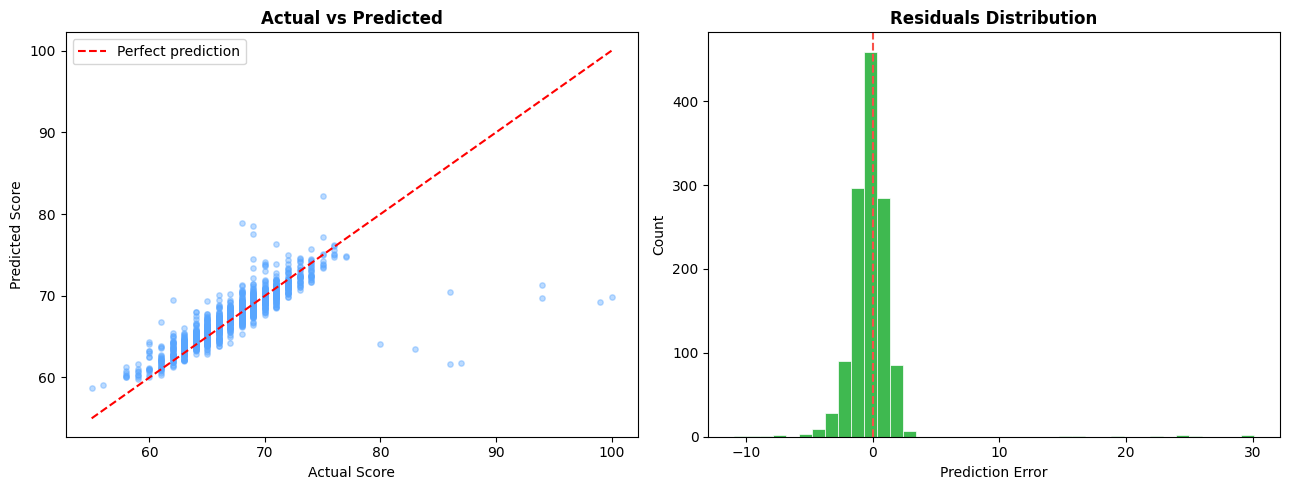

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color="#58a6ff")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted", fontweight="bold")
axes[0].set_xlabel("Actual Score")
axes[0].set_ylabel("Predicted Score")
axes[0].legend()

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color="#3fb950", edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="#f85149", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals Distribution", fontweight="bold")
axes[1].set_xlabel("Prediction Error")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature Importance

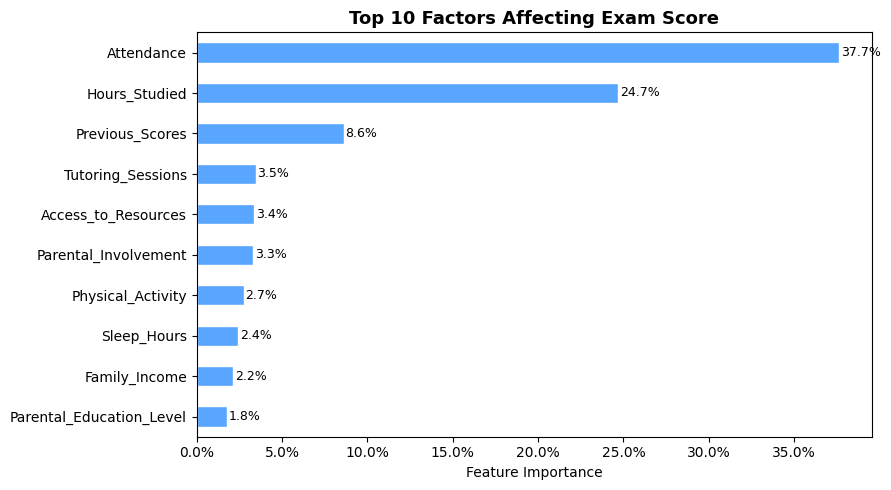

Top 5 factors:
  1. Attendance: 37.7%
  2. Hours_Studied: 24.7%
  3. Previous_Scores: 8.6%
  4. Tutoring_Sessions: 3.5%
  5. Access_to_Resources: 3.4%


In [19]:
feature_names = ORDINAL_COLS + BINARY_COLS + NUM_COLS

importances = pd.Series(
    pipeline.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top10 = importances.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
top10.plot(kind="barh", ax=ax, color="#58a6ff", edgecolor="white")
ax.set_title("Top 10 Factors Affecting Exam Score", fontweight="bold", fontsize=13)
ax.set_xlabel("Feature Importance")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
for bar, val in zip(ax.patches, top10.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 factors:")
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp*100:.1f}%")

## 9. Study Hours Analysis

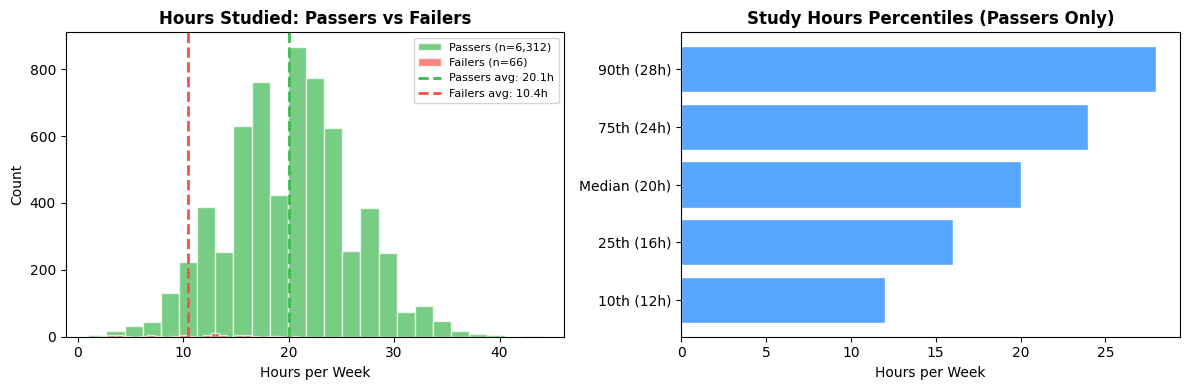

Passers — Mean: 20.1h | Median: 20h
Failers — Mean: 10.4h | Median: 12h


In [22]:
passers = df[df["Exam_Score"] >= 60]
failers = df[df["Exam_Score"] < 60]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(passers["Hours_Studied"], bins=25, alpha=0.7,
             color="#3fb950", label=f"Passers (n={len(passers):,})", edgecolor="white")
axes[0].hist(failers["Hours_Studied"], bins=25, alpha=0.7,
             color="#f85149", label=f"Failers (n={len(failers):,})", edgecolor="white")
axes[0].axvline(passers["Hours_Studied"].mean(), color="#3fb950", linestyle="--",
                linewidth=2, label=f'Passers avg: {passers["Hours_Studied"].mean():.1f}h')
axes[0].axvline(failers["Hours_Studied"].mean(), color="#f85149", linestyle="--",
                linewidth=2, label=f'Failers avg: {failers["Hours_Studied"].mean():.1f}h')
axes[0].set_title("Hours Studied: Passers vs Failers", fontweight="bold")
axes[0].set_xlabel("Hours per Week")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

quantiles = passers["Hours_Studied"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
labels = [f"10th ({int(quantiles[0.10])}h)", f"25th ({int(quantiles[0.25])}h)",
          f"Median ({int(quantiles[0.50])}h)", f"75th ({int(quantiles[0.75])}h)",
          f"90th ({int(quantiles[0.90])}h)"]
axes[1].barh(labels, quantiles.values, color="#58a6ff", edgecolor="white")
axes[1].set_title("Study Hours Percentiles (Passers Only)", fontweight="bold")
axes[1].set_xlabel("Hours per Week")

plt.tight_layout()
plt.savefig("hours_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Passers — Mean: {passers['Hours_Studied'].mean():.1f}h | Median: {passers['Hours_Studied'].median():.0f}h")
print(f"Failers — Mean: {failers['Hours_Studied'].mean():.1f}h | Median: {failers['Hours_Studied'].median():.0f}h")

## 10. Save the Pipeline

One file contains everything — preprocessor + model. The Streamlit app loads this and calls `pipeline.predict(raw_df)` directly on raw string inputs. No manual encoding. No bugs.

In [ ]:
joblib.dump(pipeline, "models/pipeline.joblib")
print("pipeline.joblib saved ✅")
print()
print("Contents:")
print("  ├── ColumnTransformer (preprocessor)")
print("  │   ├── OrdinalEncoder  → 8 ordinal cols (Low/Med/High → 0/1/2)")
print("  │   ├── OrdinalEncoder  → 5 binary cols  (Yes/No → 0/1)")
print("  │   └── MinMaxScaler    → 6 numeric cols (0 to 1)")
print("  └── RandomForestRegressor (200 trees)")
print()
print("In your Streamlit app:")
print("  pipeline = joblib.load('pipeline.joblib')")
print("  score    = pipeline.predict(raw_df)[0]")

pipeline.joblib saved ✅

Contents:
  ├── ColumnTransformer (preprocessor)
  │   ├── OrdinalEncoder  → 8 ordinal cols (Low/Med/High → 0/1/2)
  │   ├── OrdinalEncoder  → 5 binary cols  (Yes/No → 0/1)
  │   └── MinMaxScaler    → 6 numeric cols (0 to 1)
  └── RandomForestRegressor (200 trees)

In your Streamlit app:
  pipeline = joblib.load('pipeline.joblib')
  score    = pipeline.predict(raw_df)[0]


## 11. Summary

| Metric | Value |
|--------|-------|
| Dataset | 6,607 students, 19 features |
| Model | Random Forest (200 trees) |
| R² Score | ~0.68 |
| MAE | ~2.0 points |
| Pipeline file | 1 × pipeline.joblib |

### Key Findings
1. **Attendance #1** (~38%) — bigger than hours studied
2. **Hours Studied #2** (~25%) — directly controllable
3. **Previous Scores #3** (~9%)
4. Passers study ~20 hrs/week; failers ~10 hrs/week

### Pipeline Flow
```
Raw DataFrame
     ↓
ColumnTransformer
  ├── OrdinalEncoder  (Low/Med/High → 0/1/2)
  ├── OrdinalEncoder  (Yes/No → 0/1)
  └── MinMaxScaler    (numerics → 0–1)
     ↓
RandomForestRegressor
     ↓
Predicted Exam Score
```

---
*Built by Ameer Hamza Nasir — [github.com/ipycharmer](https://github.com/ipycharmer)*